In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

In [ ]:
wd = 0.6365091993031
tlist = np.linspace(0, 200, 400)
nlist = [4, 10]
d = 1.0
reals = 200

full_scar = []
full_qubit = []

for N in nlist:
    H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)

    Rtau_scar = np.zeros(len(tlist))
    args = {"A": 0.1, "omega": wd}
    for _ in range(reals):
        H1, driveWeights = get_scar_H1(N, basisList, ds_dis=d)
        H = qt.QobjEvo([H0_clean, [H1, coeff]], args=args)
        psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0_clean])
        Rtau = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0]))
        Rtau_scar += Rtau
    Rtau_scar = Rtau_scar / reals

    Rtau_qubit = np.zeros(len(tlist))
    qargs = {"A": 0.1, "omega": 1.0}
    for _ in range(reals):
        qH0_list, qH1_list, driveWeights = get_qubit_ham(N, ds_dis=d)
        
        dE_tot = 0
        bw_tot = 0
        for qH0, qH1 in zip(qH0_list, qH1_list):
            qeigenvalues, qeigenstates = qH0.eigenstates()
            bw_tot += qeigenvalues[-1] - qeigenvalues[0]
    
            qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
            qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
            dE_tot = dE_tot + np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])
    
        Rtau_qubit += dE_tot / bw_tot
    Rtau_qubit = Rtau_qubit / reals

    full_scar.append(Rtau_scar)
    full_qubit.append(Rtau_qubit)

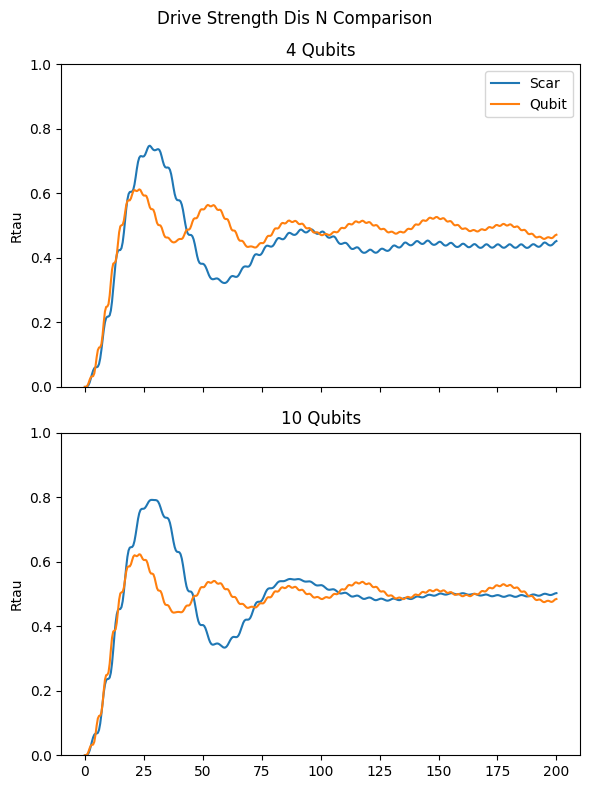

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(6, 8), sharex=True)
fig.suptitle("Drive Strength Dis N Comparison")

axs[0].plot(tlist, full_scar[0], label="Scar")
axs[0].plot(tlist, full_qubit[0], label="Qubit")
axs[0].set_title("4 Qubits")
axs[0].set_ylabel("Rtau")
axs[0].legend()

axs[1].plot(tlist, full_scar[1], label="Scar")
axs[1].plot(tlist, full_qubit[1], label="Qubit")
axs[1].set_title("10 Qubits")
axs[1].set_ylabel("Rtau")

axs[0].set_ylim(0, 1)
axs[1].set_ylim(0, 1)

plt.savefig(f"figures/amp_N{N}_dis{d}_reals{reals}.pdf")
plt.tight_layout()
plt.show()